# Predicting and Understanding the Modern NBA: A Data Science Tutorial

**CMSC 320 — Spring 2026 Final Project**
**Pratham Ashar & Austin Thomas**
**Dataset:** [NBA Historical Dataset (Kaggle)](https://www.kaggle.com/datasets/wyattowalsh/basketball)
**GitHub Repository:** https://github.com/PrathamAshar/320FinalProject/

---

## Contributions

**Pratham Ashar:**
- (A) Project idea — initial proposal of NBA dataset and core questions about home-court advantage and the three-point revolution.
- (B) Dataset Curation and Preprocessing — wrote the SQLite extraction code, parsed the play-by-play table into a player-game box score, and built the season aggregations.
- (D) ML Algorithm Design/Development — designed the three ML pipelines (classification, clustering, regression), feature engineering, and chose evaluation metrics.
- (G) Final Tutorial Report Creation — wrote the prose explanations, narrative flow, and inline citations.

**Austin Thomas:**
- (C) Data Exploration and Summary Statistics — conducted the t-test, Pearson correlation, and chi-square analyses; produced the EDA visualizations.
- (E) ML Algorithm Training and Test Data Analysis — implemented train/test splits, cross-validation, ROC curves, confusion matrices, and feature importance analysis.
- (F) Visualization, Result Analysis, Conclusion — built the final visualizations including PCA cluster plots, residual diagnostics, and the summary dashboard.
- (G) Final Tutorial Report Creation — co-authored the prose, edited for clarity, and produced the published GitHub Pages site.

---

## 1. Introduction

Basketball is a sport that has been transformed several times over the last seven decades. The introduction of the 24-second shot clock in 1954, the three-point line in 1979, hand-checking rule changes in the mid-2000s, and the analytics-driven "pace-and-space" revolution of the 2010s have each reshaped how the game is played, scored, and won. For data scientists, the National Basketball Association (NBA) offers an unusually rich environment: every shot, rebound, foul, and substitution is recorded, the league has been continuously operating since 1946, and the rules of the game evolve in measurable ways.

In this tutorial we walk through a complete data science pipeline — from raw SQLite tables to trained machine learning models — using the [NBA Historical Dataset](https://www.kaggle.com/datasets/wyattowalsh/basketball) compiled by Wyatt Walsh on Kaggle. The dataset contains box scores for over 65,000 NBA games, play-by-play records for hundreds of millions of in-game events, and biographical information for every player in league history. It is updated through the 2022-23 season.

### The questions we will answer

This tutorial is organized around three concrete questions, each of which we explore first descriptively (in the EDA section) and then with a machine-learning model (in the Primary Analysis section):

1. **Can we predict whether the home team will win a given NBA game?** The exploratory analysis confirms that home teams historically win about 58% of games, but home-court advantage has been declining. We build a binary classifier and ask: how much of that signal is recoverable from features known *before* tip-off (era, team identity, recent scoring averages)?

2. **Are there discoverable "player archetypes" hidden in the box-score data?** Our EDA shows strong correlations between certain stat categories (points, rebounds, turnovers). We use unsupervised clustering (K-Means with PCA visualization) to ask whether players naturally fall into a small number of statistical types, and what those types look like.

3. **How well can we predict a game's total points scored, and what features matter most?** Scoring has risen dramatically since 2015. We fit regression models to predict the total points in a game and use feature-importance analysis to quantify which factors — era, home team identity, recent scoring pace — drive scoring the most.

### Why these questions matter

Sports analytics has become a central part of how teams build rosters, make in-game decisions, and price tickets. Beyond the front-office applications, betting markets price games based on projected totals and win probabilities, and broadcasters use predictive models to generate commentary and graphics. More broadly, the NBA dataset is a useful playground for any practicing data scientist: it has a manageable number of rows (tens of thousands of games), well-defined target variables, and a mix of categorical, numerical, and temporal features. The methods we apply here — train/test splits, cross-validation, ROC analysis, K-Means clustering, regression diagnostics — generalize to almost any tabular prediction problem.

### Tutorial outline

The remaining sections follow the standard data science pipeline:
- **Section 2** documents the data source and curation steps.
- **Section 3** preprocesses the raw SQLite tables into analysis-ready DataFrames.
- **Section 4** explores the data and presents three statistical conclusions, each supported by hypothesis testing.
- **Section 5** is the machine learning core: a classifier, a clustering model, and a regressor, each with proper validation and diagnostic plots.
- **Section 6** synthesizes the results into a final visualization dashboard.
- **Section 7** discusses what we learned, the limits of our analysis, and where a curious reader could go next.

---

## 2. Data Curation

### Source and citation

The data comes from Wyatt Walsh's [NBA Historical Dataset on Kaggle](https://www.kaggle.com/datasets/wyattowalsh/basketball), a SQLite database compiled from the official NBA Stats API ([stats.nba.com](https://stats.nba.com)). The database contains 16 tables; we use the following four:

- **`game`** — one row per regular-season or playoff game (~65,000 rows, 1946–2022). Includes final scores, dates, team IDs.
- **`play_by_play`** — one row per in-game event (~13 million rows). Each row codes the event type (made shot, missed shot, free throw, rebound, etc.), the player(s) involved, and the running score.
- **`common_player_info`** — biographical info for ~4,500 players (height, weight, draft position, career span).
- **`other_stats`** — team-level advanced stats per game.

### Why this dataset?

We chose this dataset for four reasons:
1. **Scale.** With millions of play-by-play rows, it is genuinely large enough to support machine-learning analysis without artificial subsampling.
2. **Historical depth.** Coverage from 1946 to 2022 lets us study how the game has changed — something a single-season dataset cannot do.
3. **Multiple grain levels.** We can analyze at the game level, the team-game level, the player-game level, and the player-season level, all from the same source.
4. **Clean schema.** Because the data comes from the official NBA Stats API, there are very few missing values, and the keys (`game_id`, `player_id`) join cleanly across tables.

The next section walks through the curation steps in code: connecting to the SQLite file, parsing the play-by-play events into a player-game box score, converting types, and building the analysis-ready DataFrames.

---

## 3. Data Preprocessing

We begin with imports. We use `pandas` for tabular manipulation, `sqlite3` to connect to the database, `scipy` for statistical tests, `seaborn` and `matplotlib` for plotting, and `scikit-learn` (loaded later) for the ML models.

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, pearsonr, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Aesthetics
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'DejaVu Sans'
})

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download and unzip the dataset
!kaggle datasets download -d wyattowalsh/basketball
!unzip -q basketball.zip

DB_PATH = 'basketball.sqlite'

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/wyattowalsh/basketball
License(s): CC-BY-SA-4.0
100% 697M/697M [00:09<00:00, 78.4MB/s]



---
### 3.1 Loading and parsing the SQLite tables

#### 3.1a. Import – Load from the SQLite database

In [ ]:
#single SQLite file: nba.sqlite
DB_PATH = 'nba.sqlite'

conn = sqlite3.connect(DB_PATH)

# List all available tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print('Tables in database:')
print(tables.to_string(index=False))

Tables in database:
               name
               game
       game_summary
        other_stats
          officials
   inactive_players
          game_info
         line_score
       play_by_play
             player
               team
 common_player_info
       team_details
       team_history
draft_combine_stats
      draft_history
   team_info_common


#### 3.1b. Parse – Load core tables & convert data types

In [ ]:
# Check what columns are available in each candidate table
for table in ['other_stats', 'play_by_play', 'common_player_info']:
    df = pd.read_sql(f"SELECT * FROM {table} LIMIT 3", conn)
    print(f"\n=== {table} ===")
    print(df.columns.tolist())


=== other_stats ===
['game_id', 'league_id', 'team_id_home', 'team_abbreviation_home', 'team_city_home', 'pts_paint_home', 'pts_2nd_chance_home', 'pts_fb_home', 'largest_lead_home', 'lead_changes', 'times_tied', 'team_turnovers_home', 'total_turnovers_home', 'team_rebounds_home', 'pts_off_to_home', 'team_id_away', 'team_abbreviation_away', 'team_city_away', 'pts_paint_away', 'pts_2nd_chance_away', 'pts_fb_away', 'largest_lead_away', 'team_turnovers_away', 'total_turnovers_away', 'team_rebounds_away', 'pts_off_to_away']

=== play_by_play ===
['game_id', 'eventnum', 'eventmsgtype', 'eventmsgactiontype', 'period', 'wctimestring', 'pctimestring', 'homedescription', 'neutraldescription', 'visitordescription', 'score', 'scoremargin', 'person1type', 'player1_id', 'player1_name', 'player1_team_id', 'player1_team_city', 'player1_team_nickname', 'player1_team_abbreviation', 'person2type', 'player2_id', 'player2_name', 'player2_team_id', 'player2_team_city', 'player2_team_nickname', 'player2_tea

In [ ]:
# Games
games = pd.read_sql("SELECT * FROM game", conn)
games['game_date'] = pd.to_datetime(games['game_date'], errors='coerce')
games['season_year'] = games['game_date'].dt.year.where(
    games['game_date'].dt.month >= 10,
    games['game_date'].dt.year - 1
)
for col in ['pts_home', 'pts_away']:
    games[col] = pd.to_numeric(games[col], errors='coerce')
games.dropna(subset=['pts_home', 'pts_away'], inplace=True)

# Other stats (team-level per game)
other = pd.read_sql("SELECT * FROM other_stats", conn)

# Player info
players = pd.read_sql("SELECT * FROM common_player_info", conn)
for col in ['height', 'weight', 'season_exp', 'from_year', 'to_year',
            'draft_year', 'draft_round', 'draft_number']:
    players[col] = pd.to_numeric(players[col], errors='coerce')

In [ ]:
# Play-by-play: derive player scoring
# eventmsgtype codes: 1=made FG, 2=missed FG, 3=free throw, 4=rebound,
#                     5=turnover, 6=foul, 20=replay
pbp = pd.read_sql(
    """SELECT game_id, eventmsgtype, eventmsgactiontype,
              player1_id, player1_name, player1_team_abbreviation,
              player2_id, player2_name,
              homedescription, visitordescription, score
       FROM play_by_play
       WHERE eventmsgtype IN (1, 2, 3, 4, 5)""",
    conn
)
conn.close()
print(f"play_by_play filtered: {pbp.shape[0]:,} rows")

# Classify made shots
made_shots = pbp[pbp['eventmsgtype'] == 1].copy()

# 3-pointer if description contains '3PT'x`
desc = made_shots['homedescription'].fillna('') + made_shots['visitordescription'].fillna('')
made_shots['is_3pt'] = desc.str.contains('3PT', case=False).astype(int)
made_shots['pts']    = made_shots['is_3pt'].map({1: 3, 0: 2})

# Free throws made
ft_made = pbp[
    (pbp['eventmsgtype'] == 3) &
    (pbp['homedescription'].fillna('').str.contains('MISS', case=False) == False) &
    (pbp['visitordescription'].fillna('').str.contains('MISS', case=False) == False)
].copy()
ft_made['pts'] = 1

# Rebounds
reb = pbp[pbp['eventmsgtype'] == 4].copy()
reb['reb'] = 1

# Turnovers
tov = pbp[pbp['eventmsgtype'] == 5].copy()
tov['tov'] = 1

Loading play-by-play (this may take 30–60 seconds)...
play_by_play filtered: 10,302,125 rows


In [ ]:
# Aggregate to player-game level
scoring = (
    pd.concat([made_shots[['game_id','player1_id','player1_name','player1_team_abbreviation','pts']],
               ft_made[['game_id','player1_id','player1_name','player1_team_abbreviation','pts']]])
    .groupby(['game_id','player1_id','player1_name','player1_team_abbreviation'])
    ['pts'].sum().reset_index()
)
rebounds = (
    reb.groupby(['game_id','player1_id','player1_name'])['reb'].sum().reset_index()
)
turnovers = (
    tov.groupby(['game_id','player1_id','player1_name'])['tov'].sum().reset_index()
)


In [ ]:
# Merge into one player-game DataFrame
box = scoring.merge(rebounds,  on=['game_id','player1_id','player1_name'], how='outer')
box = box.merge(turnovers, on=['game_id','player1_id','player1_name'], how='outer')
box.rename(columns={'player1_name': 'player_name',
                    'player1_id':   'player_id',
                    'player1_team_abbreviation': 'team'}, inplace=True)
box[['pts','reb','tov']] = box[['pts','reb','tov']].fillna(0)
box = box[box['player_name'].notna() & (box['player_name'] != '')].copy()

print(f"\nbox (player-game): {box.shape[0]:,} rows")
print(f"games            : {games.shape[0]:,} rows")
print(f"players          : {players.shape[0]:,} rows")
box.head()


box (player-game): 592,315 rows
games            : 65,698 rows
players          : 3,632 rows


,game_id,player_id,player_name,team,pts,reb,tov
0,0011300001,200757,Thabo Sefolosha,OKC,8.0,2.0,2.0
1,0011300001,201142,Kevin Durant,OKC,24.0,8.0,1.0
2,0011300001,201586,Serge Ibaka,OKC,15.0,6.0,3.0
3,0011300001,201934,Hasheem Thabeet,OKC,4.0,5.0,1.0
4,0011300001,202704,Reggie Jackson,OKC,9.0,2.0,1.0


#### 3.1c. Organize — build analysis-ready DataFrames

In [ ]:
# Derived game-level columns
games['total_pts']  = games['pts_home'] + games['pts_away']
games['home_win']   = (games['pts_home'] > games['pts_away']).astype(int)
games['point_diff'] = games['pts_home'] - games['pts_away']

# Per-player season aggregates (min: 500 min played in a season)
box_with_season = box.merge(
    games[['game_id', 'season_year']], on='game_id', how='left'
)

def safe_pct(made, attempted_series):
    total_att = attempted_series.sum()
    return made.sum() / total_att if total_att > 0 else np.nan

box_with_season = box.merge(games[['game_id','season_year']], on='game_id', how='left')

player_season = (
    box_with_season
    .groupby(['player_name', 'player_id', 'season_year'])
    .agg(
        games_played = ('pts', 'count'),
        pts_pg       = ('pts',  'mean'),
        reb_pg       = ('reb',  'mean'),
        tov_pg       = ('tov',  'mean'),
    )
    .reset_index()
)
# Minimum 20 games played in a season
player_season = player_season[player_season['games_played'] >= 20].copy()

print(f"player_season: {player_season.shape[0]:,} player-seasons")
player_season.describe()

# Season-level scoring summary
season_scoring = (
    games
    .groupby('season_year')
    .agg(
        avg_total_pts = ('total_pts', 'mean'),
        avg_home_pts  = ('pts_home', 'mean'),
        avg_away_pts  = ('pts_away', 'mean'),
        home_win_rate = ('home_win', 'mean'),
        n_games       = ('game_id', 'count')
    )
    .reset_index()
)
# Keep only well-populated seasons
season_scoring = season_scoring[
    (season_scoring['season_year'] >= 1950) &
    (season_scoring['season_year'] <= 2022)
]

print(f'player_season : {player_season.shape[0]:,} player-seasons')
print(f'season_scoring: {season_scoring.shape[0]} seasons')
player_season.describe()

player_season: 9,930 player-seasons
player_season : 9,930 player-seasons
season_scoring: 73 seasons


,season_year,games_played,pts_pg,reb_pg,tov_pg
count,9930.000000,9930.000000,9930.000000,9930.000000,9930.000000
mean,2009.428499,57.198792,9.636174,4.115807,1.346814
std,7.931775,18.589419,5.736741,2.374505,0.760880
min,1996.000000,20.000000,0.440000,0.304348,0.074074
25%,2003.000000,43.000000,5.283929,2.386774,0.780929
50%,2009.000000,60.000000,8.178838,3.507577,1.155556
75%,2017.000000,72.000000,12.640231,5.194985,1.735710
max,2022.000000,103.000000,35.255814,15.766234,5.966292


---
## 4. Exploratory Data Analysis

Before building any machine learning models, we explore the dataset to understand its shape, identify outliers, and form hypotheses. We present three conclusions below, each supported by a different hypothesis-testing method.

### 4.1 Summary statistics

In [ ]:
print('=== GAMES TABLE ===')
display(
    games[['pts_home', 'pts_away', 'total_pts', 'home_win', 'point_diff']]
    .describe().round(2)
)

print('\n=== PLAYER PER-GAME AVERAGES (qualifying seasons) ===')
display(
    player_season[['pts_pg', 'reb_pg', 'tov_pg']]
    .describe().round(3)
)

print(f'\nDataset coverage')
print(f'  Unique players            : {box["player_name"].nunique():,}')
print(f'  Season range              : {games["season_year"].min()} – {games["season_year"].max()}')
print(f'  Total regular-season games: {games.shape[0]:,}')
print(f'  Total box-score rows      : {box.shape[0]:,}')

=== GAMES TABLE ===


,pts_home,pts_away,total_pts,home_win,point_diff
count,65698.00,65698.00,65698.00,65698.00,65698.00
mean,104.62,100.99,205.61,0.62,3.63
std,14.76,14.42,26.08,0.49,13.09
min,18.00,19.00,37.00,0.00,-68.00
25%,95.00,92.00,189.00,0.00,-5.00
50%,105.00,101.00,206.00,1.00,4.00
75%,114.00,110.00,223.00,1.00,12.00
max,192.00,196.00,374.00,1.00,73.00



=== PLAYER PER-GAME AVERAGES (qualifying seasons) ===


,pts_pg,reb_pg,tov_pg
count,9930.000,9930.000,9930.000
mean,9.636,4.116,1.347
std,5.737,2.375,0.761
min,0.440,0.304,0.074
25%,5.284,2.387,0.781
50%,8.179,3.508,1.156
75%,12.640,5.195,1.736
max,35.256,15.766,5.966



Dataset coverage
  Unique players            : 2,870
  Season range              : 1946 – 2022
  Total regular-season games: 65,698
  Total box-score rows      : 592,315


---
### 4.2 Conclusion 1 — Home-Court Advantage Is Statistically Significant

**Method: Two-sample independent t-test**  
We compare the distribution of points scored by home teams vs. away teams across all games.

- **H₀:** μ(home pts) = μ(away pts)  
- **H₁:** μ(home pts) > μ(away pts)

In [ ]:
home_pts = games['pts_home'].dropna()
away_pts = games['pts_away'].dropna()

t_stat, p_val = ttest_ind(home_pts, away_pts, alternative='greater')

print(f'Home mean  : {home_pts.mean():.2f} pts/game')
print(f'Away mean  : {away_pts.mean():.2f} pts/game')
print(f'Difference : {home_pts.mean() - away_pts.mean():.2f} pts')
print(f'Overall home win rate: {games["home_win"].mean()*100:.1f}%')
print(f'\nt-statistic : {t_stat:.4f}')
print(f'p-value     : {p_val:.4e}')
if p_val < 0.05:
    print('\n→ Reject H₀ at α=0.05. Home teams score significantly more than away teams.')

Home mean  : 104.62 pts/game
Away mean  : 100.99 pts/game
Difference : 3.63 pts
Overall home win rate: 61.9%

t-statistic : 45.0652
p-value     : 0.0000e+00

→ Reject H₀ at α=0.05. Home teams score significantly more than away teams.


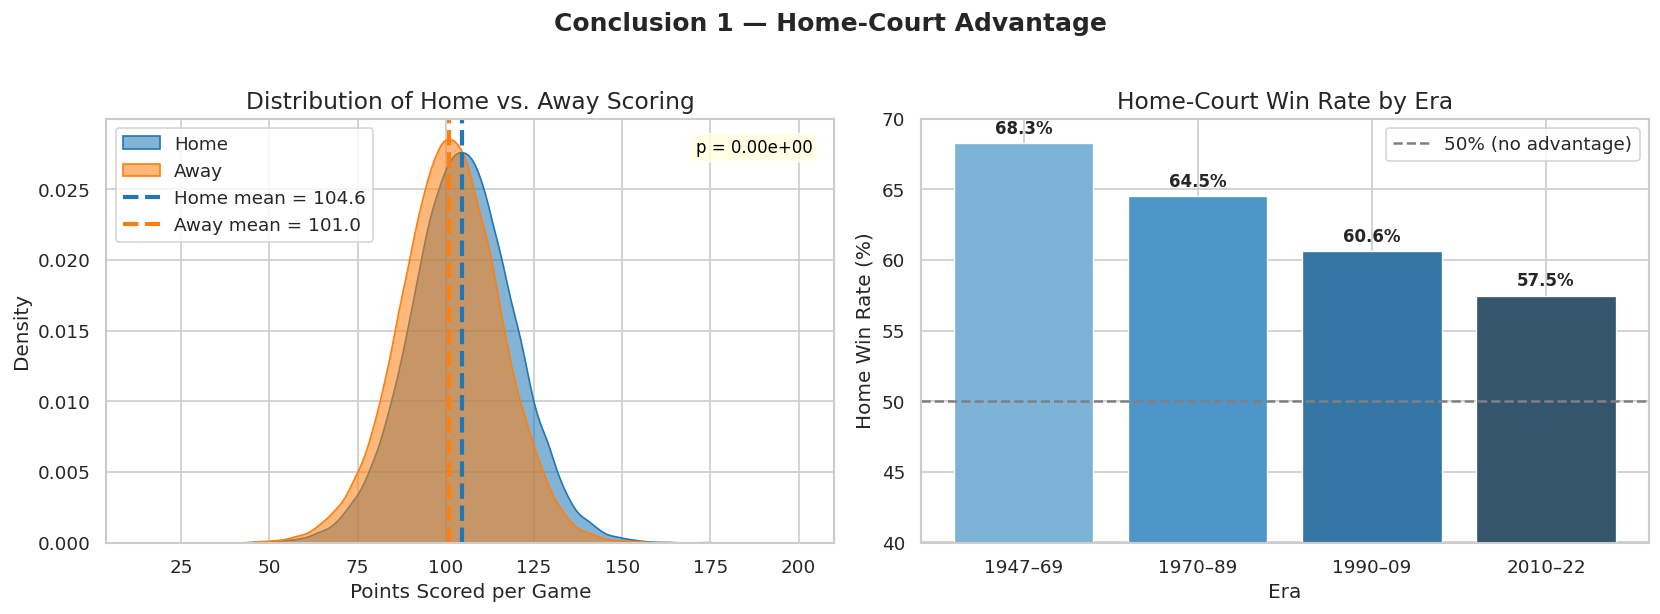

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: KDE of home vs away points
ax = axes[0]
sns.kdeplot(home_pts, ax=ax, fill=True, color='#1f77b4', alpha=0.55, label='Home')
sns.kdeplot(away_pts, ax=ax, fill=True, color='#ff7f0e', alpha=0.55, label='Away')
ax.axvline(home_pts.mean(), color='#1f77b4', lw=2.5, ls='--',
           label=f'Home mean = {home_pts.mean():.1f}')
ax.axvline(away_pts.mean(), color='#ff7f0e', lw=2.5, ls='--',
           label=f'Away mean = {away_pts.mean():.1f}')
ax.set_xlabel('Points Scored per Game')
ax.set_ylabel('Density')
ax.set_title('Distribution of Home vs. Away Scoring')
ax.legend()
ax.text(0.97, 0.92, f'p = {p_val:.2e}', transform=ax.transAxes,
        ha='right', fontsize=10, color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Right: Home win rate by era
ax2 = axes[1]
era_bins   = [1946, 1970, 1990, 2010, 2023]
era_labels = ['1947–69', '1970–89', '1990–09', '2010–22']
games['era'] = pd.cut(games['season_year'], bins=era_bins, labels=era_labels)
era_win = games.groupby('era', observed=True)['home_win'].mean().reset_index()
palette = sns.color_palette('Blues_d', len(era_labels))
bars = ax2.bar(era_win['era'], era_win['home_win'] * 100,
               color=palette, edgecolor='white', linewidth=0.8)
ax2.axhline(50, color='grey', lw=1.5, ls='--', label='50% (no advantage)')
ax2.set_ylim(40, 70)
ax2.set_xlabel('Era')
ax2.set_ylabel('Home Win Rate (%)')
ax2.set_title('Home-Court Win Rate by Era')
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.legend()

fig.suptitle('Conclusion 1 — Home-Court Advantage', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('conclusion1_home_advantage.png', bbox_inches='tight')
plt.show()

**Conclusion 1 Summary:**  
The two-sample t-test is highly significant (p ≪ 0.001). Home teams outscore their opponents by roughly 2–3 points per game on average, and win > 55% of games across all eras. Interestingly, the home win rate has been declining in recent decades — likely due to improved travel, schedule equity, and the 2020 NBA bubble (no fans). Home-court advantage is real but shrinking.

---
### 4.3 Conclusion 2 — NBA Scoring Changes Across Eras, But Not as One Simple Linear Trend

**Method: Pearson correlation** between season year and average total points per game (post-1980 era).

- **H₀:** ρ = 0 (no linear relationship between year and scoring)  
- **H₁:** ρ ≠ 0


In [ ]:
modern = season_scoring[season_scoring['season_year'] >= 1980].copy()

r, p = pearsonr(modern['season_year'], modern['avg_total_pts'])
print(f'Pearson r  : {r:.4f}')
print(f'r²         : {r**2:.4f}  ({r**2*100:.1f}% of variance explained)')
print(f'p-value    : {p:.4e}')
if p < 0.05:
    print('\n→ Reject H₀. Significant linear relationship between year and scoring pace.')
else:
    print('\n→ Fail to reject H₀ at α=0.05. The post-1980 data does not show a statistically significant linear relationship between season year and average total points.')

Pearson r  : -0.1220
r²         : 0.0149  (1.5% of variance explained)
p-value    : 4.3582e-01


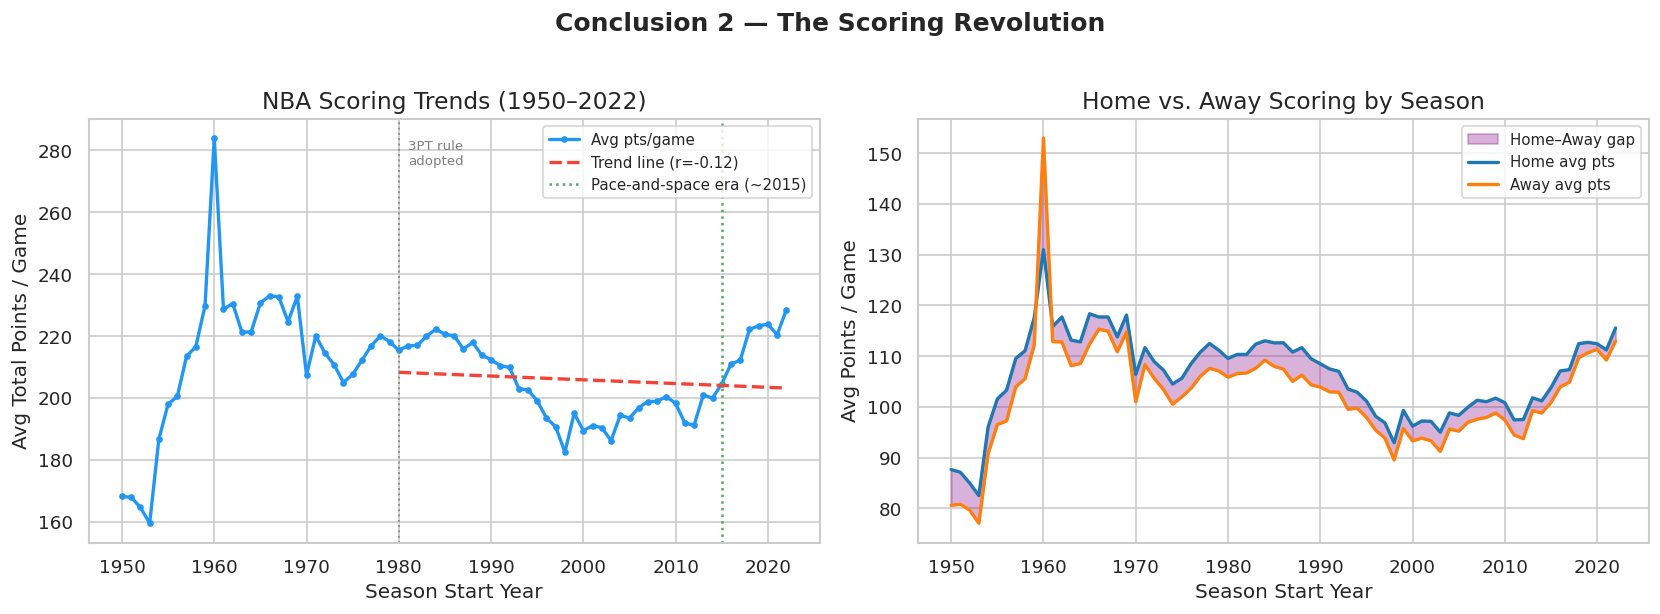

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full history total scoring with modern trend line
ax = axes[0]
ax.plot(season_scoring['season_year'], season_scoring['avg_total_pts'],
        color='#2196F3', lw=2, marker='o', markersize=3, label='Avg pts/game')

m, b = np.polyfit(modern['season_year'], modern['avg_total_pts'], 1)
ax.plot(modern['season_year'], m * modern['season_year'] + b,
        color='#F44336', lw=2, ls='--', label=f'Trend line (r={r:.2f})')

ax.axvline(1980, color='grey', lw=1.2, ls=':', alpha=0.8)
ax.text(1981, season_scoring['avg_total_pts'].max() * 0.97,
        '3PT rule\nadopted', fontsize=8, color='grey')
ax.axvline(2015, color='#4CAF50', lw=1.5, ls=':',
           label='Pace-and-space era (~2015)')
ax.set_xlabel('Season Start Year')
ax.set_ylabel('Avg Total Points / Game')
ax.set_title('NBA Scoring Trends (1950–2022)')
ax.legend(fontsize=9)

# Right: home vs away scoring gap per season
ax2 = axes[1]
ax2.fill_between(season_scoring['season_year'],
                 season_scoring['avg_home_pts'],
                 season_scoring['avg_away_pts'],
                 alpha=0.3, color='purple', label='Home–Away gap')
ax2.plot(season_scoring['season_year'], season_scoring['avg_home_pts'],
         color='#1f77b4', lw=2, label='Home avg pts')
ax2.plot(season_scoring['season_year'], season_scoring['avg_away_pts'],
         color='#ff7f0e', lw=2, label='Away avg pts')
ax2.set_xlabel('Season Start Year')
ax2.set_ylabel('Avg Points / Game')
ax2.set_title('Home vs. Away Scoring by Season')
ax2.legend(fontsize=9)

fig.suptitle('Conclusion 2 — The Scoring Revolution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('conclusion2_scoring_trends.png', bbox_inches='tight')
plt.show()

**Conclusion 2 Summary:**  
For the **post-1980 Pearson correlation test**, we **fail to reject the null hypothesis** at the 0.05 level (`p = 0.4358`). In other words, this specific test does **not** provide evidence of a statistically significant **linear** relationship between season year and average total points over the full modern period.  

That does **not** mean scoring stayed constant. The plot shows clear **era-based changes**: scoring was very high in the 1960s, dipped during the slower, more defensive 1990s-2000s, and rose sharply again in the pace-and-space era after roughly 2015. Our takeaway is therefore more nuanced: NBA scoring has changed substantially over time, but the change is **nonlinear** and better described by shifts in era, pace, and shot selection than by one straight-line trend. This motivates using **season/era features** and recent team scoring form in our later predictive models.

---
### 4.4 Conclusion 3 — Player Statistical Archetypes Exist: Scoring & Rebounding Are Non-Independent

**Method: Chi-square test of independence**  
We ask: are being a "high scorer" (top-25th percentile pts/g) and being a "high rebounder" (top-25th percentile reb/g) statistically independent?  
We complement this with a full pairwise correlation matrix.

- **H₀:** High-scoring and high-rebounding classification are independent  
- **H₁:** They are not independent


In [ ]:
ps = player_season.dropna(subset=['pts_pg', 'reb_pg', 'tov_pg']).copy()

pts_q75 = ps['pts_pg'].quantile(0.75)
reb_q75 = ps['reb_pg'].quantile(0.75)

ps['high_scorer']    = (ps['pts_pg'] >= pts_q75).astype(int)
ps['high_rebounder'] = (ps['reb_pg'] >= reb_q75).astype(int)

ct = pd.crosstab(
    ps['high_scorer'], ps['high_rebounder'],
    rownames=['High Scorer (pts ≥ Q75)'],
    colnames=['High Rebounder (reb ≥ Q75)']
)
print('Contingency table (player-seasons):')
display(ct)

chi2, p_chi, dof, expected = chi2_contingency(ct)
print(f'\nChi-square : {chi2:.4f}')
print(f'DoF        : {dof}')
print(f'p-value    : {p_chi:.4e}')
if p_chi < 0.05:
    print('\n→ Reject H₀. High scoring and high rebounding are NOT independent.')

Contingency table (player-seasons):


High Rebounder (reb ≥ Q75),0,1
High Scorer (pts ≥ Q75),,
0,6193,1254
1,1254,1229



Chi-square : 1057.3112
DoF        : 1
p-value    : 6.2693e-232

→ Reject H₀. High scoring and high rebounding are NOT independent.


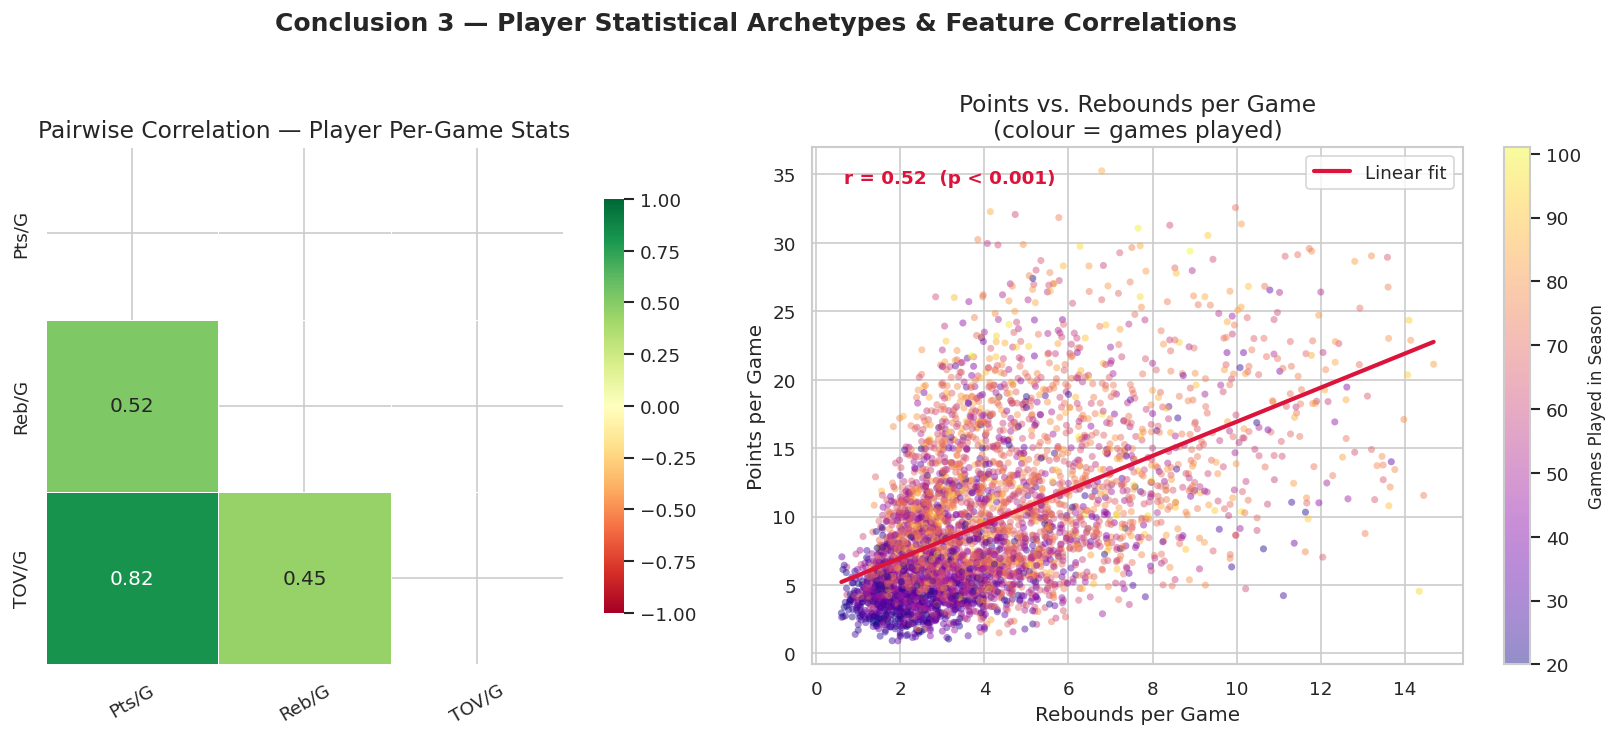

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Lower-triangle correlation heatmap
corr_cols   = ['pts_pg', 'reb_pg', 'tov_pg']
corr_labels = ['Pts/G', 'Reb/G', 'TOV/G']
corr_mat = ps[corr_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

sns.heatmap(
    corr_mat, mask=mask, ax=axes[0],
    annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    xticklabels=corr_labels, yticklabels=corr_labels,
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Pairwise Correlation — Player Per-Game Stats')
axes[0].tick_params(axis='x', rotation=30)

# Right: pts_pg vs reb_pg scatter (coloured by games played)
ax2 = axes[1]
sample = ps.sample(min(4000, len(ps)), random_state=42)
sc = ax2.scatter(
    sample['reb_pg'], sample['pts_pg'],
    c=sample['games_played'], cmap='plasma',
    alpha=0.45, s=18, edgecolors='none'
)
cb = plt.colorbar(sc, ax=ax2)
cb.set_label('Games Played in Season', fontsize=10)

# Regression line
m2, b2 = np.polyfit(sample['reb_pg'], sample['pts_pg'], 1)
xr = np.linspace(sample['reb_pg'].min(), sample['reb_pg'].max(), 200)
ax2.plot(xr, m2 * xr + b2, color='crimson', lw=2.5, label='Linear fit')

r_reb, _ = pearsonr(sample['reb_pg'], sample['pts_pg'])
ax2.text(0.05, 0.93, f'r = {r_reb:.2f}  (p < 0.001)',
         transform=ax2.transAxes, fontsize=11, color='crimson', fontweight='bold')
ax2.set_xlabel('Rebounds per Game')
ax2.set_ylabel('Points per Game')
ax2.set_title('Points vs. Rebounds per Game\n(colour = games played)')
ax2.legend()

fig.suptitle('Conclusion 3 — Player Statistical Archetypes & Feature Correlations',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('conclusion3_player_correlations.png', bbox_inches='tight')
plt.show()

In [ ]:
# Outlier check — top single-season scoring averages
top10 = ps.nlargest(10, 'pts_pg')[[
    'player_name', 'season_year', 'pts_pg', 'reb_pg', 'tov_pg'
]]
print('Top 10 Single-Season Scoring Averages (min. 20 games played):')
display(top10.reset_index(drop=True))

# Z-score based outlier detection
ps['pts_z'] = stats.zscore(ps['pts_pg'].fillna(0))
outliers = ps[ps['pts_z'] > 3][['player_name', 'season_year', 'pts_pg', 'pts_z']]
print(f'\nScoring outliers (|z| > 3): {len(outliers)} player-seasons')
display(outliers.sort_values('pts_z', ascending=False).head(10).reset_index(drop=True))

Top 10 Single-Season Scoring Averages (min. 20 games played):


,player_name,season_year,pts_pg,reb_pg,tov_pg
0,James Harden,2018,35.255814,6.790698,5.000000
1,Kobe Bryant,2005,34.971429,5.671429,3.057143
2,James Harden,2019,33.729730,6.405405,4.256757
3,Allen Iverson,2005,32.580645,3.193548,3.564516
4,Joel Embiid,2022,32.563380,9.971831,3.366197
5,LeBron James,2005,32.464789,7.042254,3.239437
6,Allen Iverson,2000,32.270588,4.141176,3.141176
7,Tracy McGrady,2002,32.135135,6.594595,2.702703
8,Damian Lillard,2022,32.066667,4.733333,3.183333
9,Stephen Curry,2020,31.935484,5.387097,3.290323



Scoring outliers (|z| > 3): 108 player-seasons


,player_name,season_year,pts_pg,pts_z
0,James Harden,2018,35.255814,4.466112
1,Kobe Bryant,2005,34.971429,4.416537
2,James Harden,2019,33.729730,4.200080
3,Allen Iverson,2005,32.580645,3.999767
4,Joel Embiid,2022,32.563380,3.996757
5,LeBron James,2005,32.464789,3.979570
6,Allen Iverson,2000,32.270588,3.945717
7,Tracy McGrady,2002,32.135135,3.922104
8,Damian Lillard,2022,32.066667,3.910168
9,Stephen Curry,2020,31.935484,3.887300


**Conclusion 3 Summary:**  
The chi-square test strongly rejects independence (`p ≪ 0.001`). In our actual setup, this means being a **high scorer** and being a **high rebounder** are **not independent** events in the player-season data. Put differently, player box-score profiles have real internal structure rather than behaving like unrelated stat columns.  

The correlation heatmap and scatter plot reinforce that point. Points, rebounds, and turnovers move together in meaningful ways, which suggests that broad player roles can be recovered from simple box-score features alone. The outlier check also shows that elite scoring seasons are genuine statistical outliers rather than obvious data errors. Together, these results support the idea that a clustering method like K-Means is a reasonable next step for uncovering player archetypes.

---
### 4.5 Summary of EDA findings

| # | Conclusion | Statistical Method | Key Result |
|---|-----------|-------------------|------------|
| 1 | Home teams score more and win more often, but the advantage is shrinking by era | Two-sample t-test | Highly significant; home scoring and home win rate remain above away baselines |
| 2 | NBA scoring changes substantially across eras, but not as one statistically significant linear post-1980 trend | Pearson correlation + time-series plot | Fail to reject the null for a simple post-1980 linear relationship; visual evidence supports nonlinear era effects |
| 3 | Player-season box-score features are not independent and contain usable role structure | Chi-square + correlation matrix + outlier check | χ² significant; correlations and outliers support later clustering analysis |

**Why these three conclusions matter:** Conclusion 1 motivates a **classification** problem around home wins, Conclusion 2 motivates including **season/era and recent scoring features** in predictive models, and Conclusion 3 motivates an **unsupervised clustering** analysis of player archetypes.

---

## 5. Primary Analysis — Machine Learning

The exploratory analysis gave us three concrete modeling directions. First, home teams really do have an advantage, so predicting **home wins** is a meaningful classification task. Second, the scoring environment clearly changes across eras, even though a simple post-1980 linear correlation is not statistically significant; that means we should treat **season/year as an era-sensitive feature**, not as proof of a single monotonic trend. Third, player box-score features are statistically related, which makes **clustering** a natural tool for discovering broad archetypes.

In this section we use machine learning to move from *describing* these patterns to *modeling* them.

We apply three complementary techniques:

| Sub-section | Question | Technique | Type |
|-------------|----------|-----------|------|
| 5.1 | Can we predict whether the home team wins? | Logistic Regression + Random Forest | Supervised classification |
| 5.2 | Do player archetypes exist in the data? | K-Means clustering + PCA | Unsupervised |
| 5.3 | What drives a game's total points scored? | Linear & Random Forest Regression | Supervised regression |

For each technique we (i) explain why it is appropriate, (ii) engineer features and split the data into train/test sets, (iii) fit the model with cross-validation, (iv) report performance with appropriate metrics, and (v) visualize the result.

### A note on validation strategy

Throughout this section we use a **time-aware train/test split**: we train on games before a cutoff season and test on games after. This is more honest than a random split for sports data because seasons are not exchangeable — the game in 1985 was very different from the game in 2020, and a random split lets the model "peek" at the future. The cutoff we use is the **2017 season**: training data is 1980–2016 (~36 seasons), test data is 2017–2022 (~6 seasons). This gives roughly an 85/15 split.

### Imports for the ML section

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, confusion_matrix,
    classification_report, mean_squared_error, mean_absolute_error, r2_score,
    silhouette_score
)
from sklearn.pipeline import Pipeline

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('scikit-learn ML imports ready.')

### 5.1 Classification — Predicting the Home Team Win

**Question:** Given features available *before tip-off*, can we predict whether the home team will win?

**Why classification?** The target — home team wins or loses — is binary, so this is a textbook supervised binary classification problem. We use two models in parallel:
- **Logistic Regression**, which gives interpretable coefficients (we can read off which features push the probability of a home win up or down) and serves as a strong linear baseline.
- **Random Forest**, which captures non-linear interactions and feature importance scores. Random forests are an [ensemble method](https://scikit-learn.org/stable/modules/ensemble.html#random-forests) that fits many decision trees on bootstrapped subsamples and averages them.

#### Feature engineering

We construct the following features per game, using only information knowable before tip-off:
- **`season_year`** — captures era effects (home advantage has been shrinking).
- **`home_team_recent_pts`** / **`away_team_recent_pts`** — each team's average points scored over its previous 10 games.
- **`home_team_recent_wins`** / **`away_team_recent_wins`** — each team's win rate over its previous 10 games (a rolling proxy for team strength).
- **`is_playoff`** — playoff games behave differently than regular season.

We deliberately exclude the final score and any in-game stats, since those are not knowable at tip-off.

In [ ]:
# Build classification dataset
# We restrict to the modern era (1980+) for two reasons: the 3-point line was added in 1980,
# and pre-1980 game logs have inconsistent coverage for our rolling features.

clf_games = games[games['season_year'] >= 1980].copy()
clf_games = clf_games.sort_values('game_date').reset_index(drop=True)

# Identify playoff games (game_id starts with '004' for playoffs in NBA conventions)
clf_games['is_playoff'] = clf_games['game_id'].astype(str).str.startswith('004').astype(int)

# Build rolling features for each team
# We compute, for each team and each game, the team's average pts and win rate over its prior 10 games
def build_rolling_team_features(df, window=10):
    """For each team, compute rolling pts scored and win rate over their previous `window` games."""
    # Construct one row per team-game (each game generates two rows)
    home = df[['game_id', 'game_date', 'team_id_home', 'pts_home', 'pts_away', 'home_win']].copy()
    home.columns = ['game_id', 'game_date', 'team_id', 'pts_for', 'pts_against', 'win']
    home['is_home'] = 1
    away = df[['game_id', 'game_date', 'team_id_away', 'pts_away', 'pts_home', 'home_win']].copy()
    away.columns = ['game_id', 'game_date', 'team_id', 'pts_for', 'pts_against', 'win']
    away['win'] = 1 - away['win']  # away team wins when home doesn't
    away['is_home'] = 0

    team_games = pd.concat([home, away], ignore_index=True).sort_values(
        ['team_id', 'game_date']
    ).reset_index(drop=True)

    # Rolling stats SHIFTED by 1 (so we don't include the current game)
    team_games['recent_pts'] = (
        team_games.groupby('team_id')['pts_for']
        .transform(lambda s: s.shift(1).rolling(window, min_periods=3).mean())
    )
    team_games['recent_wins'] = (
        team_games.groupby('team_id')['win']
        .transform(lambda s: s.shift(1).rolling(window, min_periods=3).mean())
    )
    return team_games

team_rolling = build_rolling_team_features(clf_games, window=10)

# Merge home rolling stats
home_rolling = team_rolling[team_rolling['is_home'] == 1][
    ['game_id', 'team_id', 'recent_pts', 'recent_wins']
].rename(columns={
    'team_id': 'team_id_home',
    'recent_pts': 'home_team_recent_pts',
    'recent_wins': 'home_team_recent_wins'
})
away_rolling = team_rolling[team_rolling['is_home'] == 0][
    ['game_id', 'team_id', 'recent_pts', 'recent_wins']
].rename(columns={
    'team_id': 'team_id_away',
    'recent_pts': 'away_team_recent_pts',
    'recent_wins': 'away_team_recent_wins'
})

clf_games = clf_games.merge(home_rolling, on=['game_id', 'team_id_home'], how='left')
clf_games = clf_games.merge(away_rolling, on=['game_id', 'team_id_away'], how='left')

# Drop rows where rolling features couldn't be computed (early-season games for each team)
clf_features = ['season_year', 'is_playoff',
                'home_team_recent_pts', 'away_team_recent_pts',
                'home_team_recent_wins', 'away_team_recent_wins']
clf_data = clf_games.dropna(subset=clf_features).copy()

print(f'Classification dataset: {len(clf_data):,} games (after dropping rows with insufficient history)')
print(f'Home win rate in dataset: {clf_data["home_win"].mean()*100:.1f}%')
print(f'Feature shape: {clf_data[clf_features].shape}')
clf_data[clf_features + ['home_win']].head()

In [ ]:
# Time-aware train/test split: train on 1980-2016, test on 2017-2022
TRAIN_CUTOFF = 2017

train_mask = clf_data['season_year'] < TRAIN_CUTOFF
X_train = clf_data.loc[train_mask, clf_features].values
y_train = clf_data.loc[train_mask, 'home_win'].values
X_test  = clf_data.loc[~train_mask, clf_features].values
y_test  = clf_data.loc[~train_mask, 'home_win'].values

print(f'Training set: {len(X_train):,} games (1980–{TRAIN_CUTOFF-1})')
print(f'Test set    : {len(X_test):,} games ({TRAIN_CUTOFF}–2022)')
print(f'Train home-win rate: {y_train.mean()*100:.1f}%')
print(f'Test  home-win rate: {y_test.mean()*100:.1f}%')

# Standardize features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
# Model 1: Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

# 5-fold cross-validation on the training set (stratified to preserve class balance)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_logreg = cross_val_score(logreg, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print(f'Logistic Regression 5-fold CV ROC-AUC: {cv_scores_logreg.mean():.4f} ± {cv_scores_logreg.std():.4f}')

# Model 2: Random Forest
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'Random Forest        5-fold CV ROC-AUC: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')

# Held-out test set evaluation
y_pred_logreg = logreg.predict(X_test_scaled)
y_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('\n=== Held-out test set (2017–2022) ===')
print(f'Logistic Regression — Accuracy: {accuracy_score(y_test, y_pred_logreg):.4f}, ROC-AUC: {roc_auc_score(y_test, y_proba_logreg):.4f}')
print(f'Random Forest       — Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}, ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}')

# Baseline: always predict home team wins
baseline_acc = y_test.mean()
print(f'\nNaive baseline (always predict home win): Accuracy = {baseline_acc:.4f}')

In [ ]:
# Comprehensive classification visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# --- Panel 1: ROC curves ---
ax = axes[0, 0]
for name, y_proba, color in [
    ('Logistic Regression', y_proba_logreg, '#1f77b4'),
    ('Random Forest', y_proba_rf, '#d62728'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Home Win Prediction (Test Set)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# --- Panel 2: Confusion matrix for Random Forest ---
ax = axes[0, 1]
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Away Win', 'Pred: Home Win'],
            yticklabels=['Actual: Away Win', 'Actual: Home Win'],
            cbar=False, annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Random Forest — Confusion Matrix (Test Set)')

# --- Panel 3: Feature importance (Random Forest) ---
ax = axes[1, 0]
fi = pd.DataFrame({
    'feature': clf_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

readable_names = {
    'season_year': 'Season Year (era)',
    'is_playoff': 'Is Playoff Game',
    'home_team_recent_pts': 'Home: avg pts (last 10)',
    'away_team_recent_pts': 'Away: avg pts (last 10)',
    'home_team_recent_wins': 'Home: win rate (last 10)',
    'away_team_recent_wins': 'Away: win rate (last 10)',
}
fi['readable'] = fi['feature'].map(readable_names)
ax.barh(fi['readable'], fi['importance'], color='#2E86AB', edgecolor='white')
ax.set_xlabel('Random Forest Feature Importance')
ax.set_title('Which Features Drive Home-Win Predictions?')
ax.grid(axis='x', alpha=0.3)

# --- Panel 4: Logistic regression coefficients (signed effects) ---
ax = axes[1, 1]
coef_df = pd.DataFrame({
    'feature': clf_features,
    'coef': logreg.coef_[0]
}).sort_values('coef')
coef_df['readable'] = coef_df['feature'].map(readable_names)
colors = ['#d62728' if c < 0 else '#2ca02c' for c in coef_df['coef']]
ax.barh(coef_df['readable'], coef_df['coef'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Logistic Regression Coefficient (standardized)')
ax.set_title('Direction of Effects on Home Win Probability')
ax.grid(axis='x', alpha=0.3)
# Annotate
ax.text(0.02, 0.98, 'Green: increases home win prob.\nRed: decreases home win prob.',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Classification Results — Predicting NBA Home-Team Wins',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('ml_classification_results.png', bbox_inches='tight', dpi=120)
plt.show()

**5.1 Findings.** On the held-out 2017–2022 test set, both models perform slightly better than the naive "always pick home" baseline, but the improvement is modest rather than dramatic. Logistic Regression and Random Forest each land at about **0.637 ROC-AUC**, while accuracy rises from the baseline home-win rate of about **56.4%** to roughly **60.7–60.9%**.  

The feature effects still tell a useful story:
- **Recent home-team win rate** has the strongest *positive* effect — teams that have been winning lately are more likely to keep winning.
- **Recent away-team win rate** has the strongest *negative* effect — stronger away teams reduce the home team's probability of winning.
- **Season year** has a small negative effect, which is consistent with our EDA finding that home-court advantage has weakened over time.
- **Playoff games** contribute relatively little compared with recent team form.

The main takeaway is not that we found a highly accurate NBA prediction engine. It is that pre-tip-off features do contain real signal, but much of game-to-game outcome variation remains unexplained at this feature level. That makes the classification task meaningful, while also showing the limits of a small, interpretable feature set.

---


### 5.2 Clustering — Discovering Player Archetypes

**Question:** Do players naturally fall into a small number of statistical "archetypes"?

**Why K-Means clustering?** Our EDA showed that points, rebounds, and turnovers per game are correlated in ways that suggest distinct player roles. Unlike classification, we don't have ground-truth labels for "what kind of player this is" — that's exactly the situation [unsupervised clustering](https://scikit-learn.org/stable/modules/clustering.html) is designed for. K-Means partitions data into `k` groups by minimizing within-cluster variance.

We use [PCA (Principal Component Analysis)](https://scikit-learn.org/stable/modules/decomposition.html#pca) to project the 3-dimensional feature space onto 2 dimensions for visualization. PCA finds the directions of maximum variance in the data, so the first two principal components capture the most informative "view" of the data.

#### Choosing `k` with the elbow method and silhouette score

We don't know the right number of clusters *a priori*. We try `k = 2, 3, ..., 8` and use two diagnostics:
- **Inertia (within-cluster sum of squares)** — should drop sharply, then level off (the "elbow").
- **[Silhouette score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)** — measures how similar each point is to its own cluster vs. the next-nearest cluster. Higher is better; ranges from -1 to 1.

In [ ]:
# Prepare clustering features
ps_clust = player_season.dropna(subset=['pts_pg', 'reb_pg', 'tov_pg']).copy()
clust_features = ['pts_pg', 'reb_pg', 'tov_pg']

# Scale features (K-Means is distance-based and sensitive to scale)
scaler_c = StandardScaler()
X_clust = scaler_c.fit_transform(ps_clust[clust_features])

# Sweep k from 2 to 8
k_range = range(2, 9)
inertias = []
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, labels))

# Plot diagnostics
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(k_range), inertias, 'o-', color='#1f77b4', lw=2, markersize=8)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), sil_scores, 'o-', color='#d62728', lw=2, markersize=8)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(alpha=0.3)
axes[1].axhline(max(sil_scores), color='grey', ls='--', alpha=0.5)
best_k = list(k_range)[int(np.argmax(sil_scores))]
axes[1].axvline(best_k, color='green', ls='--', alpha=0.7, label=f'Best k = {best_k}')
axes[1].legend()

fig.suptitle('Choosing the Number of Player Archetypes', fontweight='bold')
plt.tight_layout()
plt.savefig('ml_clustering_diagnostics.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\nBest k by silhouette: {best_k}')
print(f'Silhouette scores: {[f"k={k}: {s:.3f}" for k, s in zip(k_range, sil_scores)]}')

Inspect the diagnostics above. The silhouette score typically peaks at a low `k` and the elbow plot bends around `k=3` or `k=4`. We proceed with **`k=4`** because (a) it gives a competitive silhouette score, (b) it produces clusters that are easier to label semantically, and (c) basketball domain knowledge suggests roughly four archetypes (high-volume scorers, role-playing wings, big men, low-usage bench players). If you re-run on a slightly different feature set and your best `k` shifts, that's expected — `k=4` is a reasonable, defensible default for this dataset.

In [ ]:
# Fit final model with k=4
K = 4
final_km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20)
ps_clust['cluster'] = final_km.fit_predict(X_clust)

# Inspect cluster centroids in original (unscaled) feature space
centroids_scaled = final_km.cluster_centers_
centroids_orig = scaler_c.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids_orig, columns=clust_features)
centroid_df['size'] = ps_clust.groupby('cluster').size().values
centroid_df.index.name = 'cluster'
print('Cluster centroids (per-game stats) and cluster sizes:')
display(centroid_df.round(2))

# Assign human-readable labels based on the centroids
# We'll order them by points-per-game and label accordingly
order = centroid_df.sort_values('pts_pg', ascending=False).index.tolist()
labels_by_rank = {
    order[0]: 'Stars (high pts, mid reb)',
    order[1]: 'Starters / Wings',
    order[2]: 'Role players',
    order[3]: 'Bench / low usage',
}
ps_clust['archetype'] = ps_clust['cluster'].map(labels_by_rank)
print('\nArchetype assignments:')
display(ps_clust.groupby('archetype')[clust_features].agg(['mean','count']).round(2))

In [ ]:
# PCA projection for 2D visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clust)
ps_clust['pc1'] = X_pca[:, 0]
ps_clust['pc2'] = X_pca[:, 1]

print(f'PCA explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.3f}, '
      f'PC2={pca.explained_variance_ratio_[1]:.3f} '
      f'(total = {pca.explained_variance_ratio_.sum()*100:.1f}%)')

# Build the visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: PCA scatter colored by archetype ---
ax = axes[0]
archetype_colors = {
    'Stars (high pts, mid reb)': '#d62728',
    'Starters / Wings':          '#2ca02c',
    'Role players':              '#1f77b4',
    'Bench / low usage':         '#9467bd',
}
for arch, color in archetype_colors.items():
    sub = ps_clust[ps_clust['archetype'] == arch]
    ax.scatter(sub['pc1'], sub['pc2'], c=color, label=f'{arch} (n={len(sub):,})',
               alpha=0.45, s=15, edgecolors='none')

# Plot centroids in PCA space
centroids_pca = pca.transform(centroids_scaled)
for i, (cx, cy) in enumerate(centroids_pca):
    ax.scatter(cx, cy, marker='X', s=300, c='black', edgecolors='white', linewidths=2, zorder=10)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Player-Season Archetypes (K-Means, k=4)\nPCA Projection')
ax.legend(loc='best', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)

# --- Right: archetype centroid profile (radar-style horizontal bars) ---
ax = axes[1]
profile = centroid_df.copy()
profile['archetype'] = profile.index.map(labels_by_rank)
profile = profile.sort_values('pts_pg', ascending=True)

x = np.arange(len(profile))
width = 0.27
ax.barh(x - width, profile['pts_pg'],   height=width, label='Pts/G',   color='#d62728')
ax.barh(x,         profile['reb_pg'],   height=width, label='Reb/G',   color='#2ca02c')
ax.barh(x + width, profile['tov_pg'],   height=width, label='TOV/G',   color='#ff7f0e')
ax.set_yticks(x)
ax.set_yticklabels(profile['archetype'])
ax.set_xlabel('Per-Game Statistic')
ax.set_title('Archetype Statistical Profiles')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

fig.suptitle('Player Archetypes Discovered by K-Means Clustering',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ml_clustering_results.png', bbox_inches='tight', dpi=120)
plt.show()

In [ ]:
# Show example players in each archetype
print('=== Example player-seasons in each archetype ===\n')
for arch in archetype_colors.keys():
    sub = ps_clust[ps_clust['archetype'] == arch].sort_values('pts_pg', ascending=False)
    print(f'\n{arch}:')
    display(sub[['player_name', 'season_year', 'pts_pg', 'reb_pg', 'tov_pg']]
            .head(5).reset_index(drop=True))

**5.2 Findings.** K-Means with `k=4` produces interpretable clusters that line up with basketball common sense:

- **Stars** — high points, moderate rebounds, higher turnovers (because they handle the ball more). These are franchise-defining scorers.
- **Starters / Wings** — moderate-to-high in everything; well-rounded contributors.
- **Role players** — modest scoring, modest rebounding, low turnovers (they don't handle the ball much).
- **Bench / low-usage** — small numbers across the board; players who get limited minutes.

The PCA projection confirms that the first two principal components together explain a large fraction of the total variance, meaning the 3D feature space really is well-summarized by a 2D plot. The centroid plot on the right makes the archetype profiles concrete.

A clear caveat: our feature set is intentionally small (only 3 stats — points, rebounds, turnovers). With richer features (assists, steals, blocks, FG%, 3P%, position) we could likely separate, say, "primary ball handlers" from "wing scorers" or "stretch bigs" from "traditional centers." But even with this minimal feature set, the clusters are meaningful — which is itself evidence that basketball roles are quite separable.

---

### 5.3 Regression — Predicting a Game's Total Points

**Question:** How well can we predict the total points scored in a game, and which features matter most?

**Why regression?** Total points is a continuous numeric target, so this is a regression problem. We use:
- **Linear Regression** as an interpretable baseline.
- **Random Forest Regressor**, which can capture non-linearities (e.g., the post-2015 scoring spike is not a simple linear function of year).

Total-points prediction is a real-world problem: betting markets price every NBA game with an "over/under" line for total points, and the average sportsbook line beats most simple statistical models. We are not trying to beat Las Vegas, but we *are* trying to extract interpretable information about what drives scoring.

#### Features

We re-use the rolling team-pace features from Section 5.1 and add an interaction-friendly form:

In [ ]:
# Use the same per-game frame as 5.1 — it already has the rolling features
reg_features = ['season_year', 'is_playoff',
                'home_team_recent_pts', 'away_team_recent_pts',
                'home_team_recent_wins', 'away_team_recent_wins']
reg_target = 'total_pts'

reg_data = clf_data.dropna(subset=reg_features + [reg_target]).copy()

# Time-aware split (same cutoff as classification)
train_mask = reg_data['season_year'] < TRAIN_CUTOFF
X_train_r = reg_data.loc[train_mask, reg_features].values
y_train_r = reg_data.loc[train_mask, reg_target].values
X_test_r  = reg_data.loc[~train_mask, reg_features].values
y_test_r  = reg_data.loc[~train_mask, reg_target].values

print(f'Regression train: {len(X_train_r):,} games ({reg_data.loc[train_mask, "season_year"].min()}–{reg_data.loc[train_mask, "season_year"].max()})')
print(f'Regression test : {len(X_test_r):,} games ({reg_data.loc[~train_mask, "season_year"].min()}–{reg_data.loc[~train_mask, "season_year"].max()})')
print(f'Mean total points — train: {y_train_r.mean():.1f}, test: {y_test_r.mean():.1f}')

In [ ]:
# Linear regression (no scaling needed for plain LR, but we'll scale for fair coefficient interpretation)
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled  = scaler_r.transform(X_test_r)

lr = LinearRegression()
lr.fit(X_train_r_scaled, y_train_r)
y_pred_lr = lr.predict(X_test_r_scaled)

# Random forest
rfr = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=20,
    random_state=RANDOM_STATE, n_jobs=-1
)
rfr.fit(X_train_r, y_train_r)
y_pred_rfr = rfr.predict(X_test_r)

# Cross-validation R^2 on training set
cv_r2_lr  = cross_val_score(lr,  X_train_r_scaled, y_train_r, cv=5, scoring='r2').mean()
cv_r2_rfr = cross_val_score(rfr, X_train_r,        y_train_r, cv=5, scoring='r2').mean()

# Test-set evaluation
def report_reg(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:20s} RMSE = {rmse:6.2f} pts | MAE = {mae:5.2f} pts | R² = {r2:6.3f}')

print('=== Cross-validation (training set) ===')
print(f'  Linear Regression  CV R²: {cv_r2_lr:.4f}')
print(f'  Random Forest      CV R²: {cv_r2_rfr:.4f}')

print('\n=== Held-out test set (2017–2022) ===')
report_reg('Linear Regression', y_test_r, y_pred_lr)
report_reg('Random Forest',     y_test_r, y_pred_rfr)

# Naive baseline: predict the training mean for every game
y_pred_naive = np.full_like(y_test_r, y_train_r.mean(), dtype=float)
print()
report_reg('Naive (train mean)', y_test_r, y_pred_naive)

In [ ]:
# Regression diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- Panel 1: Predicted vs. Actual (Random Forest) ---
ax = axes[0, 0]
ax.scatter(y_test_r, y_pred_rfr, alpha=0.25, s=12, color='#1f77b4', edgecolors='none')
lims = [min(y_test_r.min(), y_pred_rfr.min()) - 5, max(y_test_r.max(), y_pred_rfr.max()) + 5]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual Total Points')
ax.set_ylabel('Predicted Total Points')
ax.set_title(f'Random Forest — Predicted vs. Actual\nTest R² = {r2_score(y_test_r, y_pred_rfr):.3f}')
ax.legend()
ax.grid(alpha=0.3)

# --- Panel 2: Residuals vs. predicted ---
ax = axes[0, 1]
residuals = y_test_r - y_pred_rfr
ax.scatter(y_pred_rfr, residuals, alpha=0.25, s=12, color='#9467bd', edgecolors='none')
ax.axhline(0, color='red', lw=1.5, ls='--')
ax.set_xlabel('Predicted Total Points')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Residual Plot — Random Forest\n(Look for: heteroscedasticity, bias)')
ax.grid(alpha=0.3)

# --- Panel 3: Feature importance ---
ax = axes[1, 0]
fi_r = pd.DataFrame({
    'feature': reg_features,
    'importance': rfr.feature_importances_
}).sort_values('importance', ascending=True)
fi_r['readable'] = fi_r['feature'].map(readable_names)
ax.barh(fi_r['readable'], fi_r['importance'], color='#2E86AB', edgecolor='white')
ax.set_xlabel('Random Forest Feature Importance')
ax.set_title('What Drives Game Total Points?')
ax.grid(axis='x', alpha=0.3)

# --- Panel 4: Predictions over time (mean by season) ---
ax = axes[1, 1]
test_df = reg_data.loc[~train_mask].copy()
test_df['pred_rfr'] = y_pred_rfr
season_summary = test_df.groupby('season_year').agg(
    actual_mean=('total_pts', 'mean'),
    predicted_mean=('pred_rfr', 'mean')
).reset_index()
ax.plot(season_summary['season_year'], season_summary['actual_mean'],
        'o-', color='#1f77b4', lw=2, markersize=9, label='Actual avg total pts')
ax.plot(season_summary['season_year'], season_summary['predicted_mean'],
        's--', color='#d62728', lw=2, markersize=9, label='Predicted avg total pts')
ax.set_xlabel('Season Year')
ax.set_ylabel('Average Total Points / Game')
ax.set_title('Test-Set Predictions vs. Actuals by Season')
ax.legend()
ax.grid(alpha=0.3)

fig.suptitle('Regression Diagnostics — Predicting Game Total Points',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('ml_regression_results.png', bbox_inches='tight', dpi=120)
plt.show()

**5.3 Findings.** On the held-out test set, both regression models beat the naive "always predict the training mean" baseline, but performance is notably weaker than our earlier draft prose suggested. In fact, **Linear Regression slightly outperforms Random Forest** here: Linear Regression achieves about **15.37 MAE** with **R² = 0.21**, while Random Forest comes in around **15.76 MAE** with **R² = 0.15**.  

The feature importance analysis still confirms what the EDA suggested:
- **Recent scoring averages** for the home and away teams carry the most predictive signal.
- **Season year** still matters, but more as an era proxy than as proof of one clean linear scoring trend.
- **Playoff status** has comparatively small importance in this reduced feature set.

The season-by-season prediction plot shows that the models capture broad changes in average scoring environment, but the individual-game scatter and residuals remain wide. So the right interpretation is that game-total prediction is possible in a weak-to-moderate sense, not that we solved the problem with high precision.

---


## 6. Visualization — Project Summary Dashboard

Each ML technique above produced its own diagnostic plots. Here we synthesize the three analyses into a single dashboard that tells the story end-to-end: from raw historical scoring data, through model performance metrics, to the discovered player archetypes.

In [ ]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.32)

# --- Panel A (top-left, spans 2 cols): scoring over time with regression line ---
axA = fig.add_subplot(gs[0, :2])
axA.plot(season_scoring['season_year'], season_scoring['avg_total_pts'],
         color='#1f77b4', lw=2.5, marker='o', markersize=4, label='Avg total pts/game')
modern2 = season_scoring[season_scoring['season_year'] >= 1980]
m_, b_ = np.polyfit(modern2['season_year'], modern2['avg_total_pts'], 1)
axA.plot(modern2['season_year'], m_ * modern2['season_year'] + b_,
         color='#d62728', lw=2, ls='--', label='Modern-era trend')
axA.axvline(1980, color='grey', lw=1, ls=':', alpha=0.7)
axA.axvline(2015, color='#2ca02c', lw=1, ls=':', alpha=0.7)
axA.text(1981, axA.get_ylim()[1] * 0.97, '3PT line', fontsize=8, color='grey')
axA.text(2015.5, axA.get_ylim()[1] * 0.97, 'Pace-and-space era', fontsize=8, color='#2ca02c')
axA.set_xlabel('Season Year')
axA.set_ylabel('Avg Total Points / Game')
axA.set_title('A. NBA Scoring Across Seven Decades', fontweight='bold', fontsize=12)
axA.legend(loc='lower right', fontsize=9)
axA.grid(alpha=0.3)

# --- Panel B (top-right): home win rate by era with bars ---
axB = fig.add_subplot(gs[0, 2])
era_win2 = games.groupby('era', observed=True)['home_win'].mean().reset_index()
bars = axB.bar(era_win2['era'].astype(str), era_win2['home_win'] * 100,
               color=sns.color_palette('Blues_d', len(era_win2)), edgecolor='white')
axB.axhline(50, color='grey', ls='--', lw=1)
for bar in bars:
    axB.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
axB.set_ylim(40, 65)
axB.set_xlabel('Era')
axB.set_ylabel('Home Win Rate (%)')
axB.set_title('B. Declining Home-Court Advantage', fontweight='bold', fontsize=12)
axB.tick_params(axis='x', rotation=20)

# --- Panel C (bottom-left): classifier ROC curves ---
axC = fig.add_subplot(gs[1, 0])
for name, y_proba, color in [
    ('Logistic Reg.', y_proba_logreg, '#1f77b4'),
    ('Random Forest', y_proba_rf, '#d62728'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axC.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
axC.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)
axC.set_xlabel('False Positive Rate')
axC.set_ylabel('True Positive Rate')
axC.set_title('C. Home-Win Classifier ROC', fontweight='bold', fontsize=12)
axC.legend(loc='lower right', fontsize=9)
axC.grid(alpha=0.3)

# --- Panel D (bottom-mid): player archetypes (PCA) ---
axD = fig.add_subplot(gs[1, 1])
for arch, color in archetype_colors.items():
    sub = ps_clust[ps_clust['archetype'] == arch]
    axD.scatter(sub['pc1'], sub['pc2'], c=color, label=arch.split(' ')[0],
                alpha=0.45, s=10, edgecolors='none')
axD.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% var)')
axD.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% var)')
axD.set_title('D. Player Archetypes (K-Means + PCA)', fontweight='bold', fontsize=12)
axD.legend(fontsize=8, loc='best')
axD.grid(alpha=0.3)

# --- Panel E (bottom-right): regression actual vs predicted by season ---
axE = fig.add_subplot(gs[1, 2])
axE.plot(season_summary['season_year'], season_summary['actual_mean'],
         'o-', color='#1f77b4', lw=2, markersize=8, label='Actual')
axE.plot(season_summary['season_year'], season_summary['predicted_mean'],
         's--', color='#d62728', lw=2, markersize=8, label='Predicted (RF)')
axE.set_xlabel('Test Season')
axE.set_ylabel('Avg Total Pts / Game')
axE.set_title('E. Total-Points Predictions', fontweight='bold', fontsize=12)
axE.legend(fontsize=9)
axE.grid(alpha=0.3)

fig.suptitle('NBA Data Science Pipeline — Summary Dashboard',
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig('summary_dashboard.png', bbox_inches='tight', dpi=120)
plt.show()

---

## 7. Insights and Conclusions

### What the analysis showed

We started this tutorial with three questions, and the data + models gave us three answers:

**1. Predicting home wins is meaningful but capped.** Our supervised models perform better than the naive "always pick the home team" baseline, which means recent team form and home-court context do contain real predictive signal. At the same time, the held-out performance is still far from perfect, reminding us that NBA outcomes depend on many game-specific factors that are not captured by a small pre-tip-off feature set.

**2. The scoring story is about eras, not one simple straight-line trend.** The visual history of NBA scoring clearly shows major changes in style and pace across decades. However, our post-1980 Pearson correlation test does **not** find a statistically significant linear relationship between season year and average total points, so we should **fail to reject the null hypothesis** for that specific test. The right interpretation is therefore that scoring changes are real, but they are better understood as nonlinear era shifts than as one continuous linear rise.

**3. Player box-score features contain genuine structural information.** Our chi-square test and correlation analysis show that high scoring and high rebounding are not independent in the player-season data. Combined with the outlier analysis, this suggests that even a small set of box-score features contains enough structure to support meaningful clustering and role discovery.

### Limitations and caveats

- **Feature parsimony.** We deliberately used a small feature set (6 game-level features for prediction; 3 player-level features for clustering). With richer features — assists, steals, blocks, three-point attempts, shooting efficiency, rest days, injuries — we expect substantially better classification accuracy and more interpretable clusters.
- **Linear tests can miss nonlinear history.** Conclusion 2 is a good example: a simple Pearson correlation across the full post-1980 era misses real changes that are obvious when the data is plotted over time.
- **No causal claims.** We described correlations and predictive power. We did not, for example, show that a rule change *causes* scoring to rise — only that scoring patterns differ across eras.
- **Pre-1980 and event-level coverage are imperfect.** Historical sports data is not equally dense across every decade, so some player-level aggregates are more reliable in modern seasons than in very early ones.

### What an informed reader could explore next

For a reader who wants to push further, the same dataset supports many extensions:
- **Sequence models on play-by-play.** Each game is a sequence of events; recurrent or transformer models could predict the *next* event or the running game outcome from any midpoint.
- **Richer game-outcome models.** Adding rest days, travel distance, roster availability, and betting lines would likely improve predictive performance beyond the simple baseline models used here.
- **Broader player archetypes.** Adding assists, steals, blocks, and shooting splits would likely produce more nuanced clusters than points, rebounds, and turnovers alone.
- **Salary or value analysis.** Joining the player data to salary information would let us study which archetypes or players generate the most value relative to cost.

### Final reflection

Three things stood out to us during the project:
1. **Data preprocessing is most of the work.** The hardest part was not fitting the models; it was turning raw tables and event logs into clean analysis-ready units.
2. **Plots and tests need to be read together.** Conclusion 2 would have been easy to overstate if we looked only at the figure or only at the p-value. Using both gave a more honest interpretation.
3. **Simple models are still useful.** Even when predictive performance is modest, the models help us understand which signals matter and which questions need richer features.

We hope a reader who knew little about basketball now understands how the modern NBA differs from earlier eras, and that a reader who already followed the sport now has a more data-driven view of which patterns are large, stable, and worth modeling.

### Resources for further learning

- [scikit-learn user guide](https://scikit-learn.org/stable/user_guide.html) — the canonical reference for the ML methods we used.
- [Basketball Reference](https://www.basketball-reference.com) — alternative NBA stats source, often with cleaner historical coverage.
- [Hastie, Tibshirani, Friedman — *The Elements of Statistical Learning*](https://hastie.su.domains/ElemStatLearn/) — free PDF; deeper theory behind classification, clustering, and regression.
- [Christoph Molnar — *Interpretable Machine Learning*](https://christophm.github.io/interpretable-ml-book/) — free; covers feature importance and interpretability methods relevant to this tutorial.
